<a href="https://colab.research.google.com/github/Ali13fffff/Heart-Disease-Prediction2/blob/main/heart_disease_modeling_stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import libraries

In [36]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

#Load Data

In [38]:
df=pd.read_csv("heart.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  1

#Cleaning Data

In [39]:
print(df.isnull().sum())
print(df.duplicated().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
0


#Creating Engineered Features

In [41]:
df["Cholesterol*Age"] = df["Cholesterol"] * df["Age"]
df["HR_per_Age"] = df["MaxHR"] / (220 - df["Age"])

#Feature Engineering

In [42]:
Category_Col = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=Category_Col, drop_first=True, dtype=int)

#Data Splitting

In [43]:
X = df.drop("HeartDisease", axis=1).copy()
y = df["HeartDisease"].copy()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### 🚀 Model Optimization Workflow
In this step, we implement a **Pipeline** that integrates SMOTE and Random Forest.
This ensures that data augmentation only happens during cross-validation,
preventing information leakage and providing more reliable evaluation metrics.

In [ ]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300,400,500],
    'model__max_depth': [1,2,4,6,8,10,20],
    'model__min_samples_split': [2, 5, 10],
}

rf_cv = RandomizedSearchCV(
    pipeline, param_grid, cv=5, n_iter=25,
    scoring='f1', n_jobs=-1, random_state=42,
)

rf_cv.fit(X_train, y_train)

print(f"Best params: {rf_cv.best_params_}")
print(f"Best F1 Score: {rf_cv.best_score_}")

# 📊 Final Model Results


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC Score: 0.9301


--- Confusion Matrix_RandomForest ---


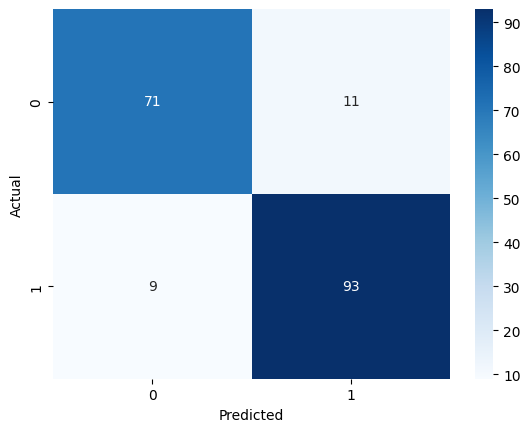

In [ ]:


best_model = rf_cv.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba=best_model.predict_proba(X_test)[:,1]


print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")


print("\n--- Confusion Matrix_RandomForest ---")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

🏆 Feature Importance for RandomForest

Feature Importance:
              Feature  Importance
16        ST_Slope_Up    0.162257
15      ST_Slope_Flat    0.149146
14   ExerciseAngina_Y    0.114337
5             Oldpeak    0.095315
6     Cholesterol*Age    0.074680
7          HR_per_Age    0.072339
4               MaxHR    0.072146
2         Cholesterol    0.064763
0                 Age    0.046199
1           RestingBP    0.042945
8               Sex_M    0.035242
3           FastingBS    0.019343
9   ChestPainType_ATA    0.017569
10  ChestPainType_NAP    0.015086
12  RestingECG_Normal    0.007448
11   ChestPainType_TA    0.005804
13      RestingECG_ST    0.005380


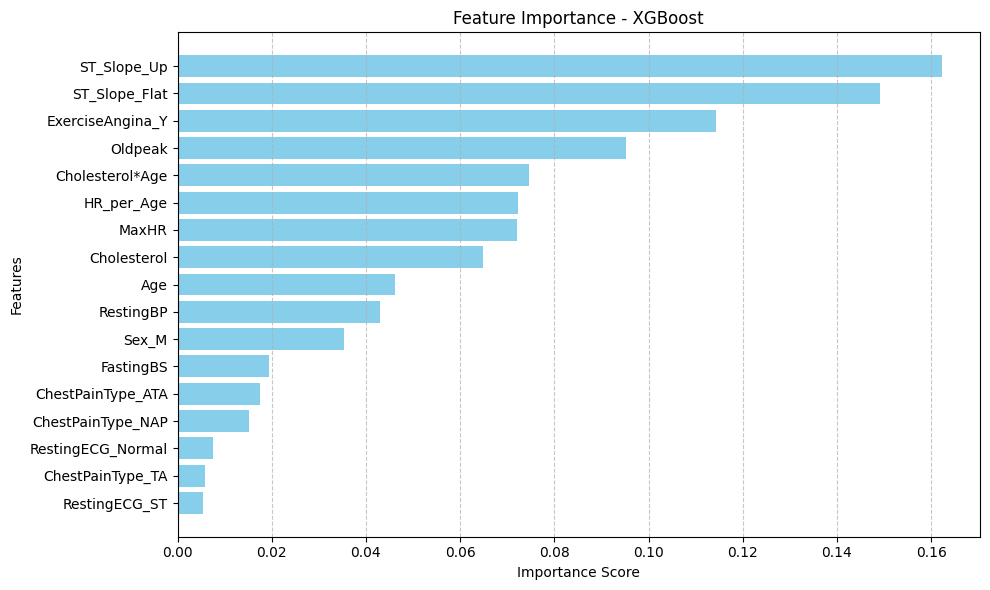

In [ ]:
importances = best_model.named_steps['model'].feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#🚀 Model Optimization Workflow(XGB)

In [ ]:


pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,))
])


param_grid_xgb = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 5, 7, 8, 10],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9]
}


xgb_cv = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_grid_xgb,
    n_iter=25,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)


xgb_cv.fit(X_train, y_train)


print("Best params:", xgb_cv.best_params_)
print("Best F1 Score:", xgb_cv.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best F1 Score: 0.8873297820375804


#📊 Final Model Results(XGB)

Best params: {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best F1 Score: 0.8873297820375804

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        82
           1       0.90      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC Score: 0.9385


--- Confusion Matrix_XGBOOST ---


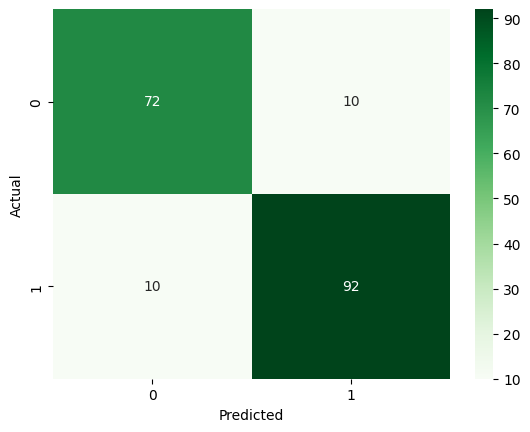

In [ ]:
best_model_xgb = xgb_cv.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)
y_pred_proba_xgb=best_model_xgb.predict_proba(X_test)[:,1]

print(f"Best params: {xgb_cv.best_params_}")
print(f"Best F1 Score: {xgb_cv.best_score_}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}\n")

print("\n--- Confusion Matrix_XGBOOST ---")
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 🏆 Feature Importance for XGBoost

Feature Importance:
              Feature  Importance
16        ST_Slope_Up    0.328878
15      ST_Slope_Flat    0.182449
14   ExerciseAngina_Y    0.101101
8               Sex_M    0.046508
2         Cholesterol    0.045446
5             Oldpeak    0.035172
7          HR_per_Age    0.030657
10  ChestPainType_NAP    0.028524
9   ChestPainType_ATA    0.028338
3           FastingBS    0.027900
0                 Age    0.024767
1           RestingBP    0.023725
4               MaxHR    0.023648
6     Cholesterol*Age    0.022967
12  RestingECG_Normal    0.019112
11   ChestPainType_TA    0.018960
13      RestingECG_ST    0.011848


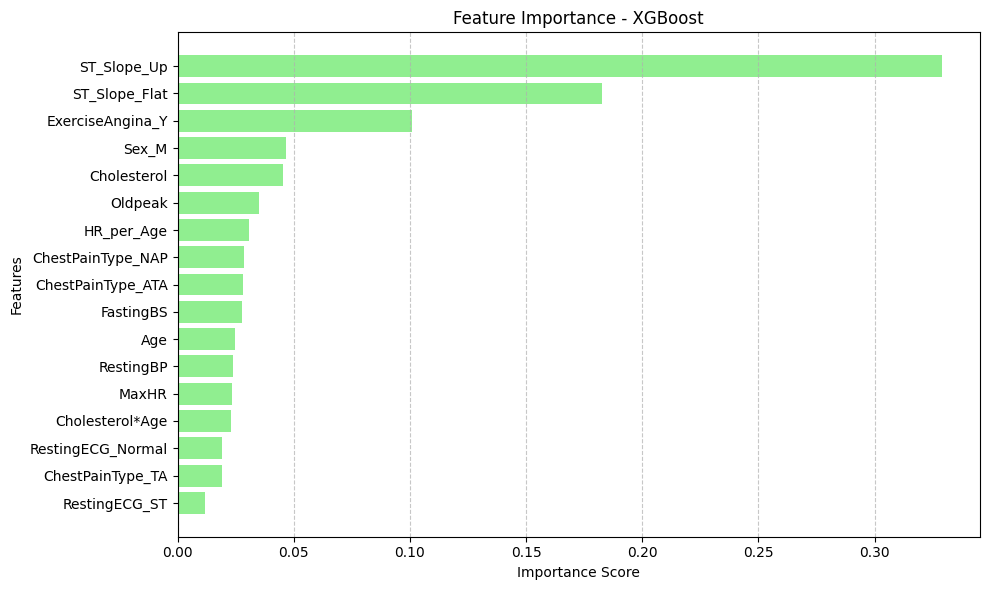

In [ ]:


importances_xgb = best_model_xgb.named_steps['model'].feature_importances_
feature_names = X_train.columns

feature_importance_xgb_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_xgb})
feature_importance_xgb_df = feature_importance_xgb_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_xgb_df)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_xgb_df['Feature'], feature_importance_xgb_df['Importance'], color='lightgreen')
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#🚀 Model Optimization Workflow(KNN)

In [ ]:



pipeline_knn =Pipeline([
    ('scaler_knn', StandardScaler()),
    ('smote_knn', SMOTE(random_state=42)),
    ('model_knn', KNeighborsClassifier())
])

param_grid_knn = {
    'model_knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'model_knn__weights': ['uniform', 'distance'],
    'model_knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_cv = RandomizedSearchCV(
    estimator=pipeline_knn,
    param_distributions=param_grid_knn,
    n_iter=25,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

knn_cv.fit(X_train, y_train)

print("Best params:", knn_cv.best_params_)
print("Best F1 Score:", knn_cv.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'model_knn__weights': 'uniform', 'model_knn__n_neighbors': 15, 'model_knn__metric': 'manhattan'}
Best F1 Score: 0.883157513377531


#📊 Final Model Results(KNN)

Best params: {'model_knn__weights': 'uniform', 'model_knn__n_neighbors': 15, 'model_knn__metric': 'manhattan'}
Best F1 Score: 0.883157513377531

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        82
           1       0.90      0.93      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.90      0.91       184
weighted avg       0.91      0.91      0.91       184

ROC-AUC Score: 0.9463


--- Confusion Matrix_KNN ---


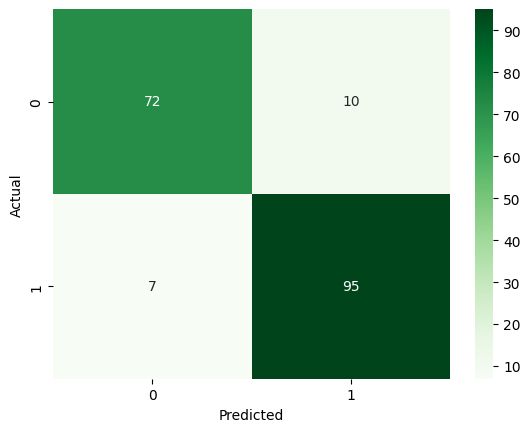

In [ ]:
best_model_knn = knn_cv.best_estimator_
y_pred_knn = best_model_knn.predict(X_test)
y_pred_proba_knn = best_model_knn.predict_proba(X_test)[:, 1]

print(f"Best params: {knn_cv.best_params_}")
print(f"Best F1 Score: {knn_cv.best_score_}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_knn))

roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)
print(f"ROC-AUC Score: {roc_auc_knn:.4f}\n")

print("\n--- Confusion Matrix_KNN ---")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#🚀 Model Optimization Workflow(Naive)

In [ ]:



pipeline_nb = Pipeline([
    ('scaler_nb', StandardScaler()),
    ('smote_nb', SMOTE(random_state=42)),
    ('model_nb', GaussianNB())
])

param_grid_nb = {
    'model_nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb_cv = RandomizedSearchCV(
    estimator=pipeline_nb,
    param_distributions=param_grid_nb,
    n_iter=5,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

nb_cv.fit(X_train, y_train)

print("Best params:", nb_cv.best_params_)
print("Best F1 Score:", nb_cv.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'model_nb__var_smoothing': 1e-09}
Best F1 Score: 0.8647867682091335


#📊 Final Model Results(Naive)

Best params: {'model_nb__var_smoothing': 1e-09}
Best F1 Score: 0.8647867682091335

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC Score: 0.9383


--- Confusion Matrix_NaiveBayes ---


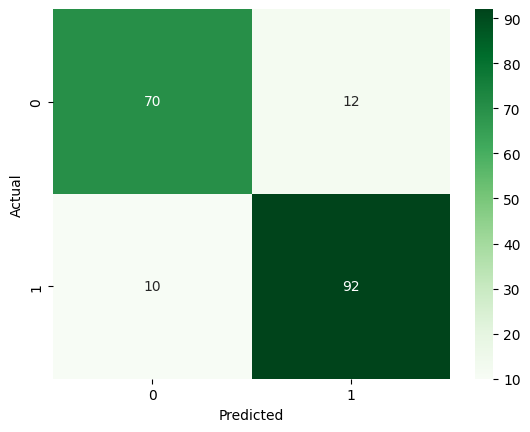

In [ ]:
best_model_nb = nb_cv.best_estimator_
y_pred_nb = best_model_nb.predict(X_test)
y_pred_proba_nb = best_model_nb.predict_proba(X_test)[:, 1]

print(f"Best params: {nb_cv.best_params_}")
print(f"Best F1 Score: {nb_cv.best_score_}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_nb))

roc_auc_nb = roc_auc_score(y_test, y_pred_proba_nb)
print(f"ROC-AUC Score: {roc_auc_nb:.4f}\n")

print("\n--- Confusion Matrix_NaiveBayes ---")
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#🚀 Model Optimization Workflow(SVM)

In [ ]:



pipeline_svm = Pipeline([
    ('scaler_svm', StandardScaler()),
    ('smote_svm', SMOTE(random_state=42)),
    ('model_svm', SVC(probability=True, random_state=42))
])

param_grid_svm = {
    'model_svm__C': [0.1, 1, 10, 100],
    'model_svm__kernel': ['linear', 'rbf', 'poly'],
    'model_svm__gamma': ['scale', 'auto']
}

svm_cv = RandomizedSearchCV(
    estimator=pipeline_svm,
    param_distributions=param_grid_svm,
    n_iter=10,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

svm_cv.fit(X_train, y_train)

print("Best params:", svm_cv.best_params_)
print("Best F1 Score:", svm_cv.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model_svm__kernel': 'rbf', 'model_svm__gamma': 'scale', 'model_svm__C': 0.1}
Best F1 Score: 0.8774206128326444


#📊 Final Model Results(SVM)

Best params: {'model_svm__kernel': 'rbf', 'model_svm__gamma': 'scale', 'model_svm__C': 0.1}
Best F1 Score: 0.8774206128326444

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        82
           1       0.88      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC Score: 0.9385


--- Confusion Matrix_SVM ---


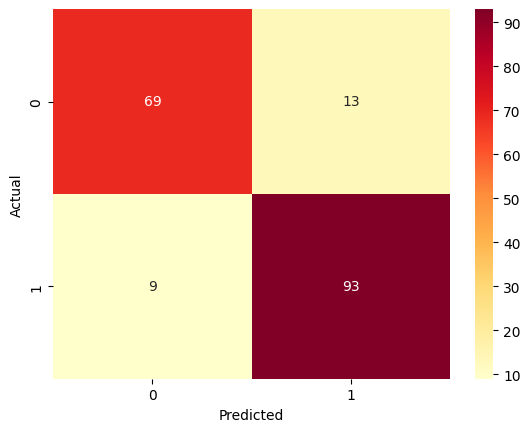

In [ ]:
best_model_svm = svm_cv.best_estimator_
y_pred_svm = best_model_svm.predict(X_test)
y_pred_proba_svm = best_model_svm.predict_proba(X_test)[:, 1]

print(f"Best params: {svm_cv.best_params_}")
print(f"Best F1 Score: {svm_cv.best_score_}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_svm))

roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
print(f"ROC-AUC Score: {roc_auc_svm:.4f}\n")

print("\n--- Confusion Matrix_SVM ---")
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='YlOrRd')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Ensemble Model: Stacking Classifier


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC Score: 0.9385

📊 Confusion Matrix:
[[71 11]
 [ 9 93]]


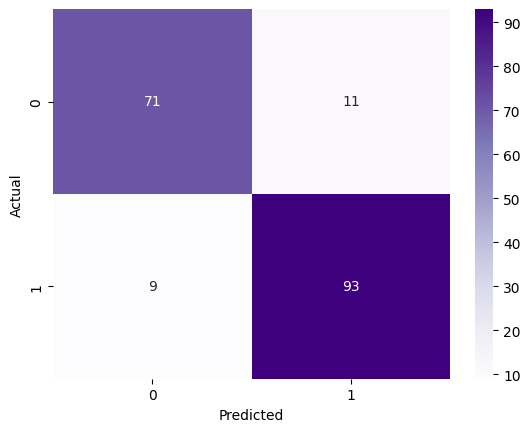

In [ ]:


stacking_model = StackingClassifier(
    estimators=[
        ('xgb', best_model),
        ('rf', best_model_xgb),
        ('knn', best_model_knn),
        ('Nai', best_model_nb),

        ('svm', best_model_svm)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

y_pred_st = stacking_model.predict(X_test)
y_pred_proba_st = stacking_model.predict_proba(X_test)[:, 1]

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_st))

roc_auc_stacking = roc_auc_score(y_test, y_pred_proba_st)
print(f"ROC-AUC Score: {roc_auc_svm:.4f}\n")


print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_st))

sns.heatmap(confusion_matrix(y_test, y_pred_st), annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Note on Model Selection:
# Although the KNN model achieved the highest raw metric scores (likely due to the small size of the dataset),
# KNN is highly sensitive to noise, outliers, and local variations in small datasets, making it prone to overfitting.
# To ensure better generalization, stability, and robustness on unseen real-world data, the Stacking Classifier
# was selected as the final model. By combining predictions from multiple diverse base learners (including
# Tree-based models, SVM, and Naive Bayes) via a Logistic Regression meta-classifier, the Stacking model reduces
# individual estimator variance and offers a more reliable and trustworthy clinical prediction.

#Save and Download Final Model

In [ ]:

joblib.dump(stacking_model,'heart_disease_model.pkl')
files.download('heart_disease_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>